In [1]:
import os
import pandas as pd

In [3]:
RESULT_DIR = "./save_results"

for file in os.listdir(RESULT_DIR):
    print(file)
    if file.find("NN") != -1:
        print(file)

fully_supervised
weakly_supervised
semi_supervised


In [15]:
os.mkdir(os.path.join(RESULT_DIR, "weakly_supervised"))

In [16]:
target = os.path.join(RESULT_DIR, "weakly_supervised")
for file in os.listdir(RESULT_DIR):
    if file.startswith("wsl"):
        os.rename(os.path.join(RESULT_DIR, file), os.path.join(target, file))

In [4]:
def get_all_csv(directory: str) -> list[str]:
    res: list[str] = []
    for file in os.listdir(directory):
        if file.endswith(".csv"):
            res.append(os.path.join(directory, file))
        if os.path.isdir(os.path.join(directory, file)):
            res.extend(get_all_csv(os.path.join(directory, file)))
    return res

In [5]:
main_dirs : list[str] = ["/fully_supervised", "/semi_supervised", "/weakly_supervised"]
main_dirs = [RESULT_DIR + sub_dir for sub_dir in main_dirs]

In [6]:
print(get_all_csv((main_dirs[0])))

['./save_results/fully_supervised/VSS_Net_NN_260527_210416/VSS_Net_result.csv', './save_results/fully_supervised/Att_UNet_NN_260527_222210/Att_UNet_result.csv', './save_results/fully_supervised/FR_UNet_3D_NN_260528_094634/FR_UNet_3D_result.csv', './save_results/fully_supervised/CSNet_3D_NN_260528_122908/CSNet_3D_result.csv', './save_results/fully_supervised/UNet_Nested_NN_260528_000323/UNet_Nested_result.csv', './save_results/fully_supervised/Res_UNet_3D_NN_260528_182747/Res_UNet_3D_result.csv', './save_results/fully_supervised/Res_UNet_NN_260528_011013/Res_UNet_result.csv', './save_results/fully_supervised/ST_UNet_NN_260529_194151/ST_UNet_result.csv', './save_results/fully_supervised/UNet_NN_260529_175103/UNet_result.csv', './save_results/fully_supervised/MAA_Net_NN_260606_084342/MAA_Net_result.csv', './save_results/fully_supervised/IPN_NN_260606_041238/IPN_result.csv', './save_results/fully_supervised/PSC_NN_260528_220236/PSC_result.csv', './save_results/fully_supervised/FR_UNet_NN_2

In [15]:
from typing import cast


def create_accumulated_df(directory: str) -> pd.DataFrame:
    csvs: list[str] = get_all_csv(directory)
    df = pd.DataFrame()
    for path in csvs:
        csv_data: pd.DataFrame = cast(pd.DataFrame, pd.read_csv(path))
        csv_data.insert(0, "type", path.split("/")[-3] + "/" + path.split("/")[-2])
        df = pd.concat([csv_data, df], ignore_index=True)
    df = df.drop(labels="Unnamed: 0", axis=1)
    return df

In [16]:
create_accumulated_df(target).to_csv(f"{target}/consolidated.csv")

./save_results/semi_supervised/FR_UNet_260530_162356/ite_2_student/FR_UNet_result.csv
./save_results/semi_supervised/FR_UNet_260530_162356/ite_1_teacher/FR_UNet_result.csv
./save_results/semi_supervised/FR_UNet_260530_162356/ite_3_student/FR_UNet_result.csv
./save_results/semi_supervised/FR_UNet_260530_162356/ite_1_student/FR_UNet_result.csv
./save_results/semi_supervised/FR_UNet_260531_074329/ite_2_student/FR_UNet_result.csv
./save_results/semi_supervised/FR_UNet_260531_074329/ite_1_teacher/FR_UNet_result.csv
./save_results/semi_supervised/FR_UNet_260531_074329/ite_3_student/FR_UNet_result.csv
./save_results/semi_supervised/FR_UNet_260531_074329/ite_1_student/FR_UNet_result.csv
./save_results/semi_supervised/FR_UNet_260531_205724/ite_2_student/FR_UNet_result.csv
./save_results/semi_supervised/FR_UNet_260531_205724/ite_1_teacher/FR_UNet_result.csv
./save_results/semi_supervised/FR_UNet_260531_205724/ite_3_student/FR_UNet_result.csv
./save_results/semi_supervised/FR_UNet_260531_205724/i

ValueError: cannot insert type, already exists

In [10]:
for path in main_dirs:
    create_accumulated_df(path).to_csv(f"{path}/consolidated.csv")

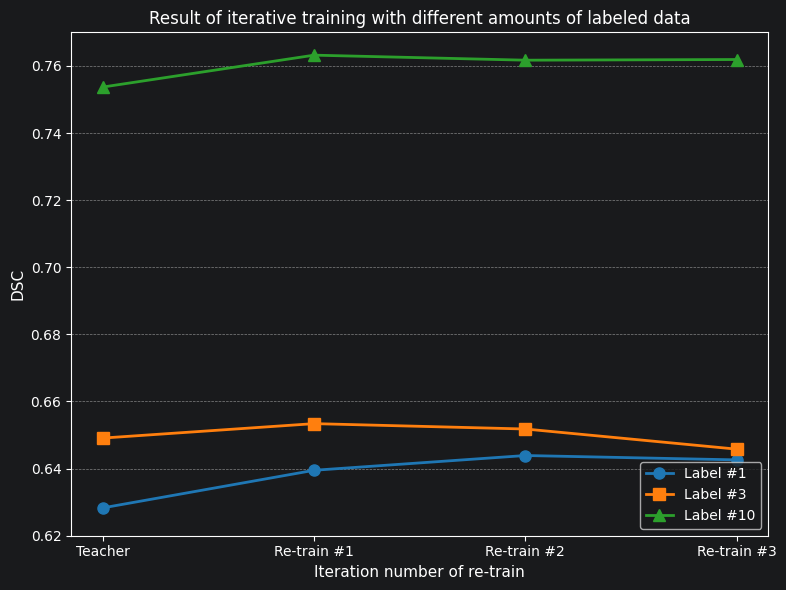

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Load the data
df = pd.read_csv('./save_results/semi_supervised/consolidated.csv')

# Mapping of the configurations to their run IDs (using the SDA + 60 unlabeled variants)
run_mappings = {
    'Label #1': 'FR_UNet_260601_060734',
    'Label #3': 'FR_UNet_260602_020818',
    'Label #10': 'FR_UNet_260602_190000'
}

# The four stages shown in Figure 9
stages = ['ite_1_teacher', 'ite_1_student', 'ite_2_student', 'ite_3_student']
x_labels = ['Teacher', 'Re-train #1', 'Re-train #2', 'Re-train #3']

# Function to extract the mean DSC value (splitting off the standard deviation)
def get_dsc_mean(val):
    if pd.isna(val):
        return np.nan
    if isinstance(val, str) and '$\pm$' in val:
        return float(val.split('$\pm$')[0])
    return float(val)

# 2. Extract the data for plotting
plot_data = {}

for label_name, run_id in run_mappings.items():
    dsc_values = []
    for stage in stages:
        # Construct the target type string
        target_type = f"{run_id}/{stage}"
        row = df[df['type'] == target_type]

        if not row.empty:
            raw_dsc = row.iloc[0]['DSC']
            dsc_values.append(get_dsc_mean(raw_dsc))
        else:
            dsc_values.append(np.nan) # Handle missing data gracefully

    plot_data[label_name] = dsc_values

# 3. Create the plot
plt.figure(figsize=(8, 6))

# Plot each line with matching colors and markers
colors = {'Label #1': '#1f77b4', 'Label #3': '#ff7f0e', 'Label #10': '#2ca02c'}
markers = {'Label #1': 'o', 'Label #3': 's', 'Label #10': '^'}

for label_name, values in plot_data.items():
    plt.plot(x_labels, values, marker=markers[label_name], color=colors[label_name],
             linewidth=2, markersize=8, label=label_name)

# 4. Customize the plot to match the paper's style
plt.title('Result of iterative training with different amounts of labeled data', fontsize=12)
plt.xlabel('Iteration number of re-train', fontsize=11)
plt.ylabel('DSC', fontsize=11)

# Set Y-axis limits to match the paper's visual scale
plt.ylim(0.62, 0.77)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='lower right')

# Show and save the plot
plt.tight_layout()
plt.savefig('fig9_recreation.png', dpi=300)
plt.show()

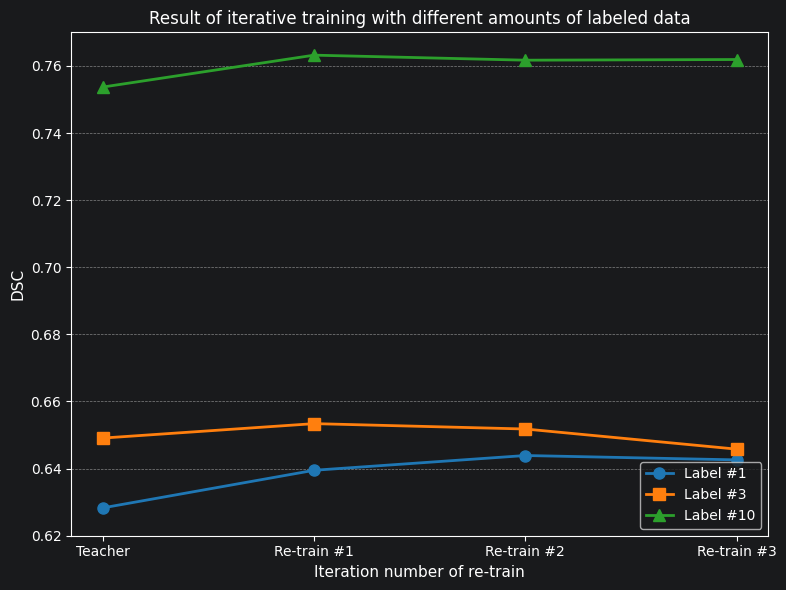

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Load the data
df = pd.read_csv('./save_results/semi_supervised/consolidated.csv')

# Mapping to the SDA + 60 unlabeled variants
run_mappings = {
    'Label #1': 'FR_UNet_260601_060734',   # 1_60_SDA
    'Label #3': 'FR_UNet_260602_020818',   # 3_60_SDA
    'Label #10': 'FR_UNet_260602_190000'   # 10_60_SDA
}

# The four stages shown in Figure 9
stages = ['ite_1_teacher', 'ite_1_student', 'ite_2_student', 'ite_3_student']
x_labels = ['Teacher', 'Re-train #1', 'Re-train #2', 'Re-train #3']

# Function to extract the mean DSC value
def get_dsc_mean(val):
    if pd.isna(val):
        return np.nan
    if isinstance(val, str) and '$\pm$' in val:
        return float(val.split('$\pm$')[0])
    return float(val)

# 2. Extract the data for plotting
plot_data = {}

for label_name, run_id in run_mappings.items():
    dsc_values = []
    for stage in stages:
        target_type = f"{run_id}/{stage}"
        row = df[df['type'] == target_type]

        if not row.empty:
            raw_dsc = row.iloc[0]['DSC']
            dsc_values.append(get_dsc_mean(raw_dsc))
        else:
            dsc_values.append(np.nan)

    plot_data[label_name] = dsc_values

# 3. Create the plot
plt.figure(figsize=(8, 6))

colors = {'Label #1': '#1f77b4', 'Label #3': '#ff7f0e', 'Label #10': '#2ca02c'}
markers = {'Label #1': 'o', 'Label #3': 's', 'Label #10': '^'}

for label_name, values in plot_data.items():
    plt.plot(x_labels, values, marker=markers[label_name], color=colors[label_name],
             linewidth=2, markersize=8, label=label_name)

# 4. Customize the plot to match the paper's style
plt.title('Result of iterative training with different amounts of labeled data', fontsize=12)
plt.xlabel('Iteration number of re-train', fontsize=11)
plt.ylabel('DSC', fontsize=11)

plt.ylim(0.62, 0.77)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='lower right')

# Show and save the plot
plt.tight_layout()
plt.savefig('fig9_recreation.png', dpi=300)
plt.show()